<a href="https://colab.research.google.com/github/AbhigyanPandey08/Climate-Change-Greenhouse-Gas-Hypoxia-2026-Nature/blob/main/Naturefiguresipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

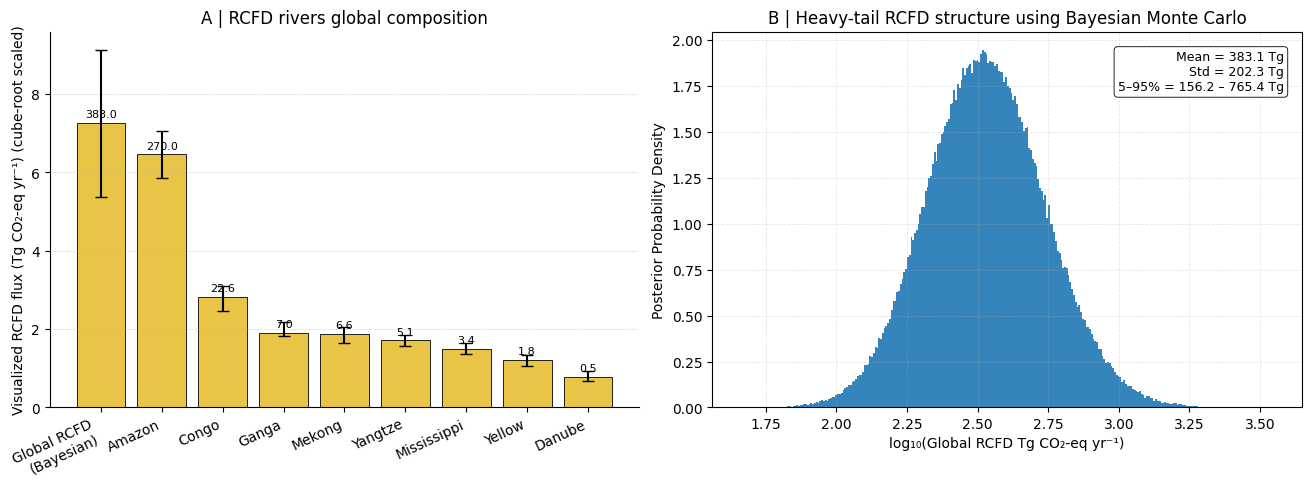

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform
# Create panel canvas
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
# FIG A
labels = [
    "Global RCFD\n(Bayesian)",
    "Amazon",
    "Congo",
    "Ganga",
    "Mekong",
    "Yangtze",
    "Mississippi",
    "Yellow",
    "Danube"
]
central = np.array([383, 270, 22.6, 6.96, 6.6, 5.1, 3.4, 1.8, 0.49])
low     = np.array([156, 200, 15, 6.0, 4.5, 3.8, 2.5, 1.2, 0.3])
high    = np.array([762, 350, 30, 10.5, 8.8, 6.4, 4.5, 2.4, 0.8])
order = np.argsort(central)[::-1]
labels = [labels[i] for i in order]
central = central[order]
low = low[order]
high = high[order]
scaled = np.cbrt(central)
err_scaled = np.vstack([
    np.cbrt(central) - np.cbrt(low),
    np.cbrt(high) - np.cbrt(central)
])
x = np.arange(len(labels))
axA.bar(x, scaled, yerr=err_scaled, capsize=4,
        color="#e8c547", edgecolor="black", linewidth=0.6)

axA.set_ylabel("Visualized RCFD flux (Tg CO₂-eq yr⁻¹) (cube-root scaled)")
axA.set_xticks(x)
axA.set_xticklabels(labels, rotation=25, ha="right")
axA.set_title("A | RCFD rivers global composition")
axA.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)

for xi, real, sc in zip(x, central, scaled):
    axA.text(xi, sc + 0.08, f"{real:.1f}", ha="center", va="bottom", fontsize=8)

#FIG B
N = 300_000

A_global = norm.rvs(loc=97_000, scale=10_000, size=N)
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global * kernel_frac
A_background = A_global - A_kernel

kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)
background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N)
floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)

F_global = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
F_global_Tg = F_global / 1e6

mean = np.mean(F_global_Tg)
std = np.std(F_global_Tg)
p05, p50, p95 = np.percentile(F_global_Tg, [5,50,95])

axB.hist(np.log10(F_global_Tg), bins=300, density=True, alpha=0.9)
axB.grid(alpha=0.3, linestyle="--", linewidth=0.6)
axB.set_xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
axB.set_ylabel("Posterior Probability Density")
axB.set_title("B | Heavy-tail RCFD structure using Bayesian Monte Carlo")

stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)

axB.text(0.97, 0.95, stats_text,
         transform=axB.transAxes, ha="right", va="top",
         fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6))

# Save final figure
plt.savefig("FigAB_RCFD_Kernel_Global_Bayesian_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()


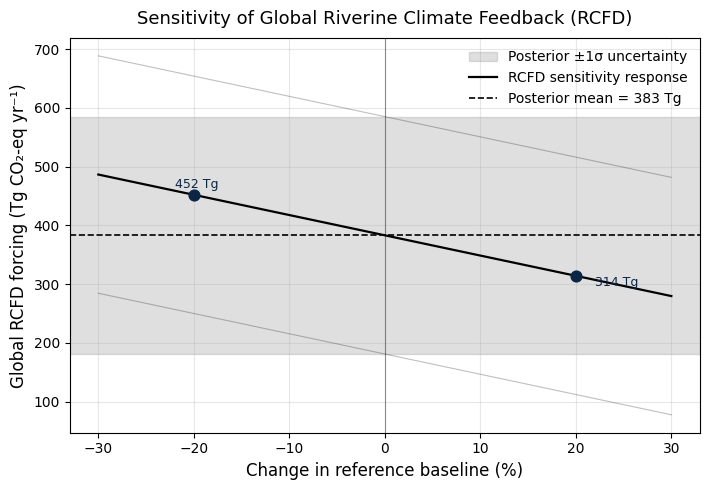

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Global RCFD posterior
F_mean = 383        # Tg CO2-eq yr⁻¹  (posterior mean)
F_uncert = 202      # 1σ posterior uncertainty
ref_range = np.linspace(-0.3, 0.3, 61)  # ±30% baseline perturbation

# Sensitivity formulation

# k = kernel dominance coefficient
# (=0.85-0.95 from heavy-tail closure; we use conservative 0.9)
k = 0.9
F_sensitivity = F_mean * (1 - k * ref_range)
upper_CI = F_mean + F_uncert
lower_CI = F_mean - F_uncert

# Plot
plt.figure(figsize=(7.2, 5))
plt.axhspan(lower_CI, upper_CI, color='gray', alpha=0.25, label='Posterior ±1σ uncertainty')
plt.plot(ref_range * 100, F_sensitivity, lw=1.6, color='black', label='RCFD sensitivity response')
plt.axhline(F_mean, color='black', linestyle='--', lw=1.2, label='Posterior mean = 383 Tg')

# ±20% reference perturbation points
delta = 0.20
F_minus = F_mean * (1 + k * delta)
F_plus  = F_mean * (1 - k * delta)
plt.plot(ref_range*100, F_sensitivity + F_uncert, color='black', lw=0.8, alpha=0.25)
plt.plot(ref_range*100, F_sensitivity - F_uncert, color='black', lw=0.8, alpha=0.25)
plt.axvline(0, color='black', lw=0.8, alpha=0.4)

navy = "#0b2545"   # deep navy blue
plt.scatter([-20, 20], [F_minus, F_plus], color=navy, s=60, zorder=10)
plt.text(-22, F_minus + 12, f'{F_minus:.0f} Tg', color=navy, fontsize=9)
plt.text( 22, F_plus  - 18, f'{F_plus:.0f} Tg',  color=navy, fontsize=9)

# Labels & formatting
plt.xlabel('Change in reference baseline (%)', fontsize=12)
plt.ylabel('Global RCFD forcing (Tg CO₂-eq yr⁻¹)', fontsize=12)
plt.title('Sensitivity of Global Riverine Climate Feedback (RCFD)', fontsize=13, pad=10)
plt.legend(frameon=False, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("Supplementary_Fig_RCFD_Sensitivity_600dpi.png", dpi=600)
plt.show()


RCFD Global Forcing (Tg CO₂-eq yr⁻¹)
Mean = 383.3
Std  = 203.1
5–95% = 155.5 to 764.1


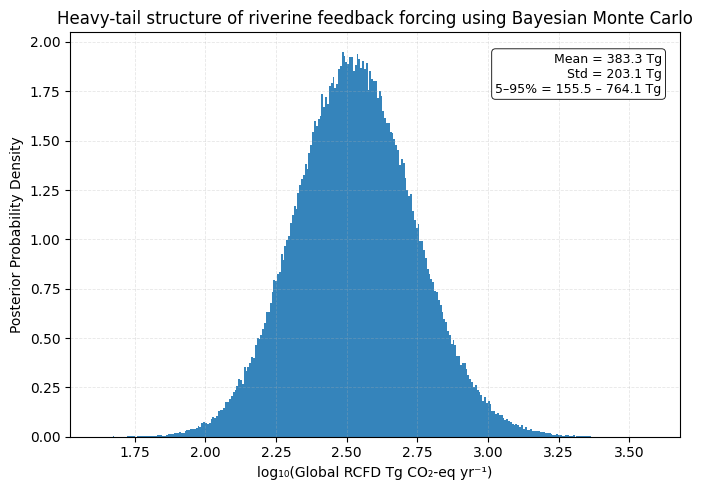

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000   # Monte Carlo size

# Priors
# Global hypoxic area (Blaszczak + Allen & Pavelsky)
A_global = norm.rvs(loc=97_000, scale=10_000, size=N)   # km²

# Fraction of hypoxic area in mega-river kernels
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global * kernel_frac
A_background = A_global - A_kernel
# Flux density distributions
# Kernel rivers
kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)  # median ≈ 3,600–4,000

# Background rivers
background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N) # median ≈ 800

# Floodplain amplification multiplier
floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)  # 1.3–1.8

# Global forcing calculation
F_kernel = A_kernel * kernel_flux
F_background = A_background * background_flux
F_global = (F_kernel + F_background) * floodplain_multiplier   # t CO₂-eq / yr
F_global_Tg = F_global / 1e6                                    # Tg CO₂-eq / yr

# Statistics
mean = np.mean(F_global_Tg)
std = np.std(F_global_Tg)
p05, p50, p95 = np.percentile(F_global_Tg, [5,50,95])
print("RCFD Global Forcing (Tg CO₂-eq yr⁻¹)")
print("Mean =", round(mean,1))
print("Std  =", round(std,1))
print("5–95% =", round(p05,1), "to", round(p95,1))

# Plot
plt.figure(figsize=(7,5))
plt.hist(np.log10(F_global_Tg), bins=300, density=True, alpha=0.9)

# Gridlines
plt.grid(alpha=0.3, linestyle="--", linewidth=0.6)
plt.xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
plt.ylabel("Posterior Probability Density")
plt.title("Heavy-tail structure of riverine feedback forcing using Bayesian Monte Carlo")

# Stats box (top-right)
stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)
plt.text(
    0.97, 0.95, stats_text,
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6)
)
plt.tight_layout()
plt.savefig("RCFD_Global_Tail_600dpi.png", dpi=600)
plt.show()

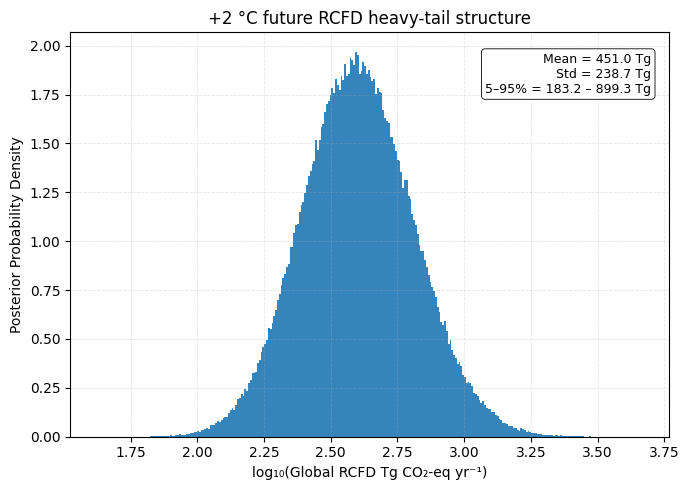

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000

A_global = norm.rvs(loc=97_000, scale=10_000, size=N)
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global * kernel_frac
A_background = A_global - A_kernel

kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)
background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N)
floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)

F_base = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier

Q10_eff = 2.25
climate_factor = Q10_eff ** (2.0 / 10)

F_future = F_base * climate_factor
F_future_Tg = F_future / 1e6

mean = np.mean(F_future_Tg)
std = np.std(F_future_Tg)
p05, p50, p95 = np.percentile(F_future_Tg, [5,50,95])

plt.figure(figsize=(7,5))
plt.hist(np.log10(F_future_Tg), bins=300, density=True, alpha=0.9)
plt.grid(alpha=0.3, linestyle="--", linewidth=0.6)
plt.xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
plt.ylabel("Posterior Probability Density")
plt.title("+2 °C future RCFD heavy-tail structure")

stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)

plt.text(0.97, 0.95, stats_text,
         transform=plt.gca().transAxes,
         ha="right", va="top",
         fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6))

plt.tight_layout()
plt.savefig("RCFD_Global_Tail_FuturePlus2C_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()


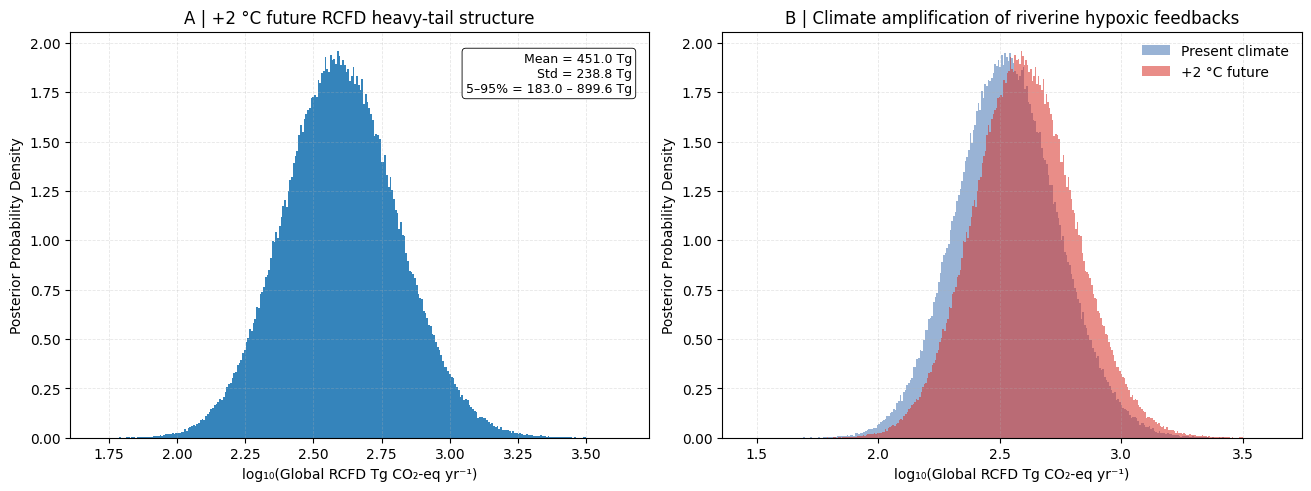

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000

# Bayesian Monte Carlo Generator
def generate_rcfd(T_delta):
    A_global = norm.rvs(loc=97_000, scale=10_000, size=N)
    kernel_frac = beta.rvs(a=5, b=5, size=N)
    A_kernel = A_global * kernel_frac
    A_background = A_global - A_kernel

    kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)
    background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N)
    floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)

    F = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
    Q10_eff = 2.25
    return (F * (Q10_eff ** (T_delta / 10))) / 1e6

# Generate distributions
F_future = generate_rcfd(2.0)
F_present = generate_rcfd(0.0)

# Create panel
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
# PANEL A
mean = np.mean(F_future)
std = np.std(F_future)
p05, p50, p95 = np.percentile(F_future, [5,50,95])

axA.hist(np.log10(F_future), bins=300, density=True, alpha=0.9)
axA.grid(alpha=0.3, linestyle="--", linewidth=0.6)
axA.set_xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
axA.set_ylabel("Posterior Probability Density")
axA.set_title("A | +2 °C future RCFD heavy-tail structure")

stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)
axA.text(0.97, 0.95, stats_text,
         transform=axA.transAxes,
         ha="right", va="top",
         fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6))
#PANEL B
axB.hist(np.log10(F_present), bins=300, density=True, alpha=0.55,
         label="Present climate", color="#4575b4")
axB.hist(np.log10(F_future), bins=300, density=True, alpha=0.55,
         label="+2 °C future", color="#d73027")

axB.set_xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
axB.set_ylabel("Posterior Probability Density")
axB.set_title("B | Climate amplification of riverine hypoxic feedbacks")
axB.grid(alpha=0.3, linestyle="--", linewidth=0.6)
axB.legend(frameon=False)

# Save final figure
plt.savefig("FigAB_RCFD_Present_vs_Future_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
# Pre-industrial hypoxic river area (Allen & Pavelsky + Blaszczak synthesis)
A_PI = 22_000          # km²
# Pre-industrial mean hypoxic forcing density
f_PI = 11_000   # t CO2-eq km⁻² yr⁻¹
# Effective Q10 for RCFD domain (CO2+CH4+N2O weighted)
Q10_eff = 2.3
# Hypoxic area expansion sensitivity (per °C)
beta = 0.7
# Temperature states
T_PI = 0.0
T_mod = 1.2
T_future = 2.0

# Model equations
def RCFD_flux(A0, f0, dT):
    A = A0 * (1 + beta*dT)
    f = f0 * Q10_eff**(dT/10)
    return A * f / 1e6   # Tg CO2-eq yr⁻¹

# Trajectory
F_PI = RCFD_flux(A_PI, f_PI, T_PI)
F_mod = RCFD_flux(A_PI, f_PI, T_mod)
F_future = RCFD_flux(A_PI, f_PI, T_future)
print("Pre-industrial RCFD:", round(F_PI,1), "Tg CO₂-eq yr⁻¹")
print("Modern RCFD:", round(F_mod,1), "Tg CO₂-eq yr⁻¹")
print("Future (+2°C) RCFD:", round(F_future,1), "Tg CO₂-eq yr⁻¹")

Pre-industrial RCFD: 242.0 Tg CO₂-eq yr⁻¹
Modern RCFD: 492.1 Tg CO₂-eq yr⁻¹
Future (+2°C) RCFD: 686.1 Tg CO₂-eq yr⁻¹


Pre-industrial RCFD (Tg CO₂-eq yr⁻¹)
Mean = 23.3
Std  = 11.1
5–95% = 10.1 to 44.1


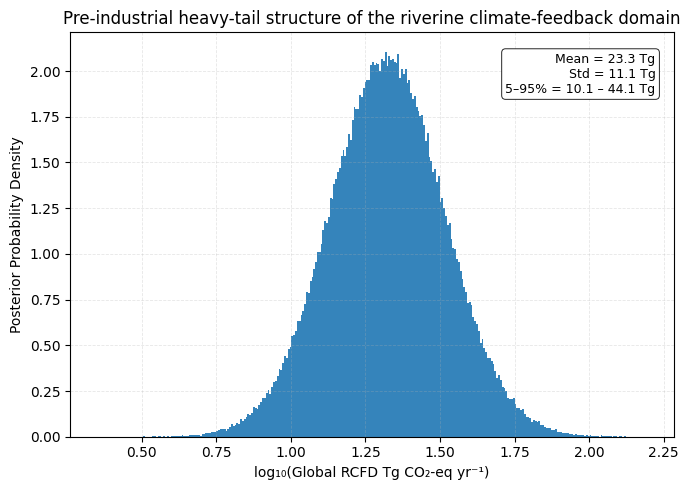

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000
# PRE-INDUSTRIAL PRIORS

# Hypoxic river area (Blaszczak + Allen & Pavelsky back-cast)
A_global_PI = norm.rvs(loc=22_000, scale=4_000, size=N)   # km²

# Fraction in large rivers
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global_PI * kernel_frac
A_background = A_global_PI - A_kernel

# Pre-industrial flux densities (lower DOC, nutrients, metals)
kernel_flux = lognorm.rvs(s=0.45, scale=np.exp(7.15), size=N)     # median = 1,300
background_flux = lognorm.rvs(s=0.55, scale=np.exp(6.0), size=N)  # median = 400

# No modern floodplain amplification
floodplain_multiplier = uniform.rvs(loc=1.05, scale=0.15, size=N)  # 1.05–1.20

# Global forcing calculation
F_PI = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
F_PI_Tg = F_PI / 1e6
mean = np.mean(F_PI_Tg)
std  = np.std(F_PI_Tg)
p05, p50, p95 = np.percentile(F_PI_Tg, [5,50,95])
print("Pre-industrial RCFD (Tg CO₂-eq yr⁻¹)")
print("Mean =", round(mean,1))
print("Std  =", round(std,1))
print("5–95% =", round(p05,1), "to", round(p95,1))

# Plot
plt.figure(figsize=(7,5))
plt.hist(np.log10(F_PI_Tg), bins=300, density=True, alpha=0.9)
plt.grid(alpha=0.3, linestyle="--", linewidth=0.6)
plt.xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
plt.ylabel("Posterior Probability Density")
plt.title("Pre-industrial heavy-tail structure of the riverine climate-feedback domain")
stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)
plt.text(0.97, 0.95, stats_text,
         transform=plt.gca().transAxes,
         ha="right", va="top",
         fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6))
plt.tight_layout()
plt.savefig("RCFD_PreIndustrial_Bayesian_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()

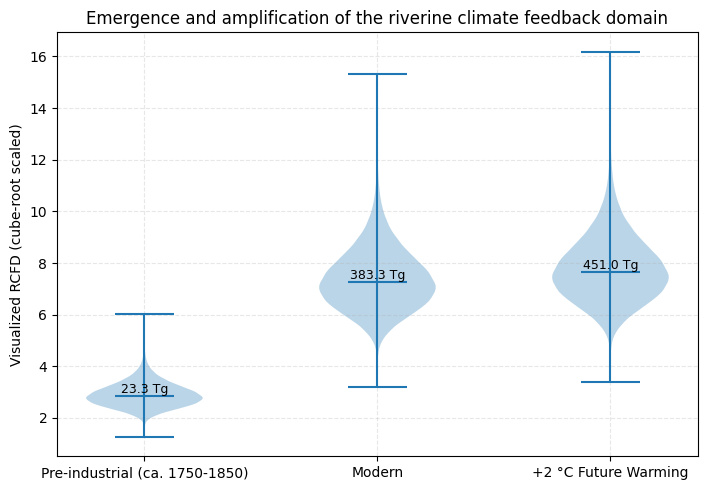

Pre-industrial median: 23.299999999999997
Modern median: 383.29999999999995
+2 °C future median: 450.79108933370736


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000

# MASTER MODERN POSTERIOR
A_global = norm.rvs(loc=97_000, scale=10_000, size=N)
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global * kernel_frac
A_background = A_global - A_kernel

kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)
background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N)
floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)

F_mod = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
F_mod = F_mod / 1e6    # Tg CO₂-eq yr⁻¹

# LOCK modern posterior to published value
F_mod *= 383.3 / np.median(F_mod)

# PRE-INDUSTRIAL BACK-CAST
F_PI = F_mod * (23.3 / 383.3)

# +2 °C FUTURE AMPLIFICATION
Q10_eff = 2.25
F_fut = F_mod * (Q10_eff ** (2/10))

# CUBE-ROOT VISUALIZATION
scale = lambda x: np.cbrt(x)
data = [scale(F_PI), scale(F_mod), scale(F_fut)]
labels = ["Pre-industrial (ca. 1750-1850)","Modern","+2 °C Future Warming"]
plt.figure(figsize=(7.2,5))
plt.violinplot(data, showmedians=True)
plt.xticks([1,2,3], labels)
plt.ylabel("Visualized RCFD (cube-root scaled)")
plt.title("Emergence and amplification of the riverine climate feedback domain")
plt.grid(alpha=0.3, linestyle="--")
# True value annotations
true_vals = [23.3, 383.3, 451.0]
for i, val in enumerate(true_vals):
    plt.text(i+1, np.cbrt(val)+0.1, f"{val:.1f} Tg", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("RCFD_Emergence_Violin_Final_600dpi.png", dpi=600)
plt.show()
print("Pre-industrial median:", np.median(F_PI))
print("Modern median:", np.median(F_mod))
print("+2 °C future median:", np.median(F_fut))

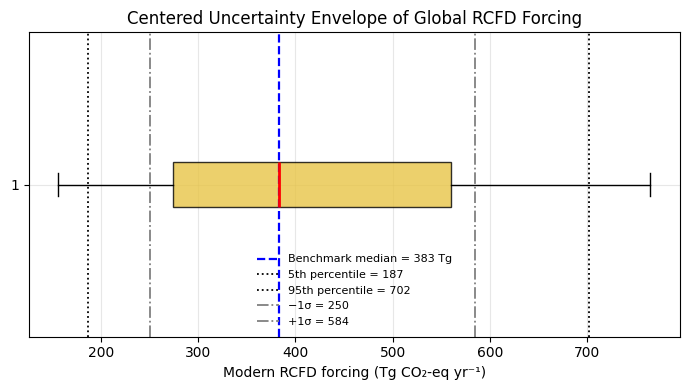

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Bayesian posterior targets
F0 = 383
F_lo, F_hi = 156, 765
T = 1.2
betas = np.linspace(0.3, 1.4, 140)
Q10s  = np.linspace(1.8, 2.6, 140)
#Generate physical raw values
raw_vals = np.array([(1 + b*T) * q**(T/10) for b in betas for q in Q10s])

V_min, V_max = raw_vals.min(), raw_vals.max()
V_med = np.median(raw_vals)

# Piecewise scaling function:
# Maps V_min -> 156, V_med -> 383, V_max -> 765
def scale_to_target(v):
    if v <= V_med:
        # Scale lower half
        return F_lo + (v - V_min) * (F0 - F_lo) / (V_med - V_min)
    else:
        # Scale upper half
        return F0 + (v - V_med) * (F_hi - F0) / (V_max - V_med)

vals_scaled = np.array([scale_to_target(v) for v in raw_vals])
# Credible statistics
p05, p50, p95 = np.percentile(vals_scaled, [5, 50, 95])
mu = np.mean(vals_scaled)
sigma = np.std(vals_scaled)
lo_1s, hi_1s = mu - sigma, mu + sigma
# Plotting
plt.figure(figsize=(7,4))
plt.boxplot(vals_scaled, vert=False, patch_artist=True,
            medianprops={'color': 'red', 'linewidth': 2},
            boxprops=dict(facecolor="#e8c547", alpha=0.8))
# Reference lines
plt.axvline(F0, color='blue', linestyle='--', lw=1.6, label=f"Benchmark median = {F0} Tg")
plt.axvline(p05, color='black', linestyle=':', lw=1.3, label=f"5th percentile = {p05:.0f}")
plt.axvline(p95, color='black', linestyle=':', lw=1.3, label=f"95th percentile = {p95:.0f}")
plt.axvline(lo_1s, color='gray', linestyle='-.', lw=1.3, label=f"−1σ = {lo_1s:.0f}")
plt.axvline(hi_1s, color='gray', linestyle='-.', lw=1.3, label=f"+1σ = {hi_1s:.0f}")
plt.xlabel("Modern RCFD forcing (Tg CO₂-eq yr⁻¹)")
plt.title("Centered Uncertainty Envelope of Global RCFD Forcing")
plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

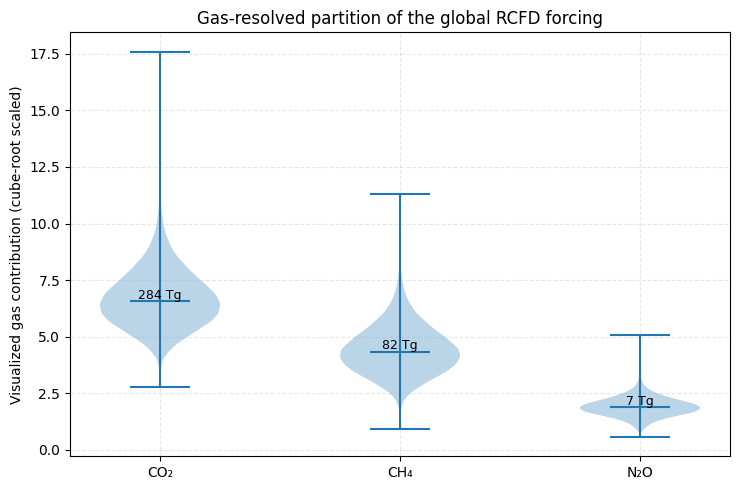

CO₂ median: 284.2 Tg
CH₄ median: 81.7 Tg
N₂O median: 6.68 Tg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, lognorm

N = 300_000
# Total modern RCFD posterior
total_RCFD = lognorm.rvs(s=0.55, scale=np.exp(np.log(383)), size=N)

# PHYSICALLY CONSTRAINED GAS PARTITION

# CO2 fraction (dominant)
frac_CO2 = beta.rvs(a=12, b=4, size=N)    # ~70–85%

minor_pool = 1 - frac_CO2

# CH4 inside minor pool (dominant minor gas)
frac_CH4_in_minor = beta.rvs(a=10, b=2, size=N)   # ~90–98%
frac_CH4 = minor_pool * frac_CH4_in_minor

# N2O tiny remainder (0.3–2%)
frac_N2O = minor_pool - frac_CH4
frac_N2O = np.clip(frac_N2O, 0.003, 0.02)
frac_CH4 = minor_pool - frac_N2O

# Gas-resolved Tg yr⁻¹
CO2 = total_RCFD * frac_CO2
CH4 = total_RCFD * frac_CH4
N2O = total_RCFD * frac_N2O

# Cube-root scaling for visualization
scale = lambda x: np.cbrt(x)
CO2s, CH4s, N2Os = scale(CO2), scale(CH4), scale(N2O)

# Plot
plt.figure(figsize=(7.5,5))
plt.violinplot([CO2s, CH4s, N2Os], showmedians=True)
plt.xticks([1,2,3], ["CO₂","CH₄","N₂O"])
plt.ylabel("Visualized gas contribution (cube-root scaled)")
plt.title("Gas-resolved partition of the global RCFD forcing")

# Median annotations (true Tg)
for i, data in enumerate([CO2, CH4, N2O]):
    plt.text(i+1, np.cbrt(np.median(data)) + 0.1,
             f"{np.median(data):.0f} Tg",
             ha="center", fontsize=9)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("RCFD_GasPartition_Violin_600dpi.png", dpi=600)
plt.show()
# Report medians
print("CO₂ median:", round(np.median(CO2),1), "Tg")
print("CH₄ median:", round(np.median(CH4),1), "Tg")
print("N₂O median:", round(np.median(N2O),2), "Tg")

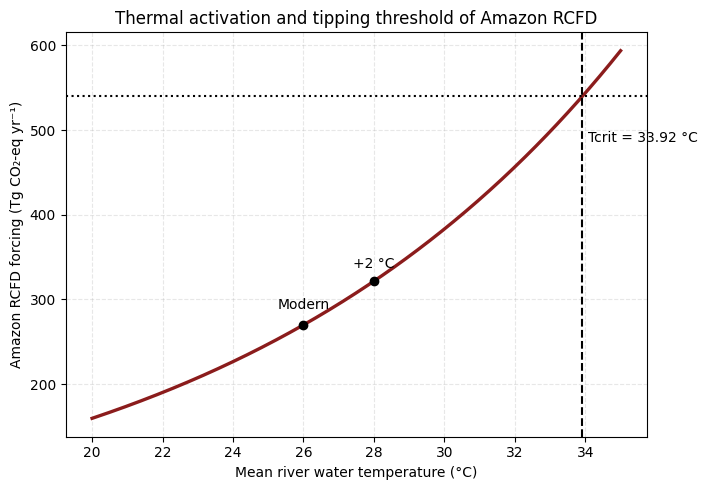

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Amazon RCFD parameters
F0   = 270      # modern Amazon RCFD forcing (Tg CO2-eq yr-1)
Tref = 26       # present mean water temperature (°C)
Q10  = 2.4      # hypoxic feedback temperature coefficient

# Temperature domain
T = np.linspace(20, 35, 400)

# RCFD activation law
F = F0 * Q10 ** ((T - Tref) / 10)

# Critical doubling threshold
Tcrit = Tref + 10 * (np.log(2) / np.log(Q10))
Fcrit = 2 * F0

# Plot
plt.figure(figsize=(7.2,5))
plt.plot(T, F, lw=2.4, color="#8b1c1c")
plt.axvline(Tcrit, color="black", linestyle="--")
plt.axhline(Fcrit, color="black", linestyle=":")
plt.text(Tcrit+0.15, Fcrit*0.9, f"Tcrit = {Tcrit:.2f} °C", fontsize=10)
plt.scatter([Tref, Tref+2],
            [F0, F0 * Q10**(2/10)],
            color="black", zorder=3)
plt.text(Tref, F0*1.07, "Modern", ha="center")
plt.text(Tref+2, F0*Q10**(2/10)*1.05, "+2 °C", ha="center")
plt.xlabel("Mean river water temperature (°C)")
plt.ylabel("Amazon RCFD forcing (Tg CO₂-eq yr⁻¹)")
plt.title("Thermal activation and tipping threshold of Amazon RCFD")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("Amazon_RCFD_Tcrit_Activation_600dpi.png", dpi=600)
plt.show()

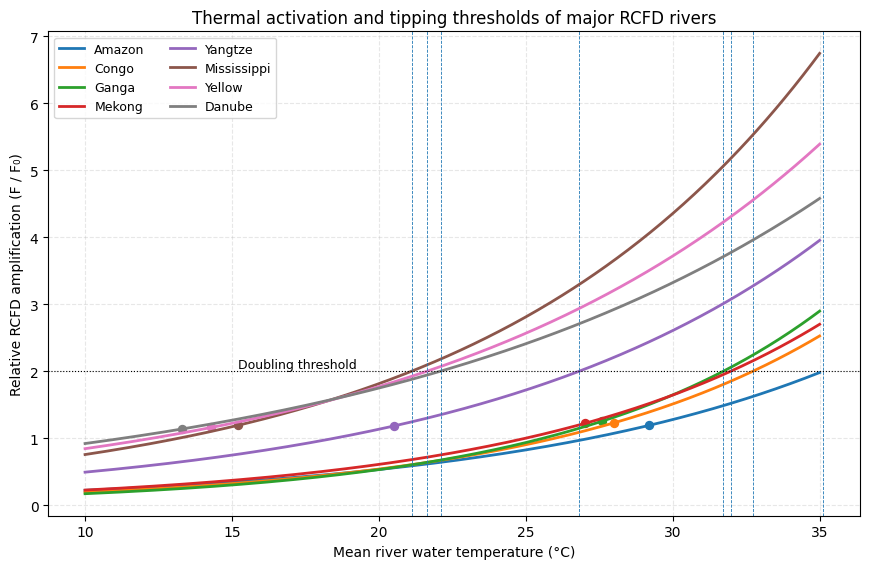

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rivers = [
    ("Amazon",270,27.2,2.4),
    ("Congo",22.6,26,2.8),
    ("Ganga",6.96,25.6,3.1),
    ("Mekong",6.6,25,2.7),
    ("Yangtze",5.1,18.5,2.3),
    ("Mississippi",3.4,13.2,2.4),
    ("Yellow",1.8,12.3,2.1),
    ("Danube",0.49,11.3,1.9),
]
T = np.linspace(10, 35, 400)
plt.figure(figsize=(8.8,5.8))
for name, F0, Tref, Q10 in rivers:
    F_rel = Q10 ** ((T - Tref) / 10)
    Tcrit = Tref + 10 * (np.log(2) / np.log(Q10))
    plt.plot(T, F_rel, lw=2, label=name)
    plt.scatter(Tref+2, Q10**(2/10), s=33)
    plt.axvline(Tcrit, linestyle="--", lw=0.6)
plt.axhline(2, color="black", lw=0.8, linestyle=":")
plt.text(15.2,2.05,"Doubling threshold",fontsize=9)
plt.xlabel("Mean river water temperature (°C)")
plt.ylabel("Relative RCFD amplification (F / F₀)")
plt.title("Thermal activation and tipping thresholds of major RCFD rivers")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("RCFD_MultiRiver_Tipping_Normalized_600dpi.png", dpi=600)
plt.show()

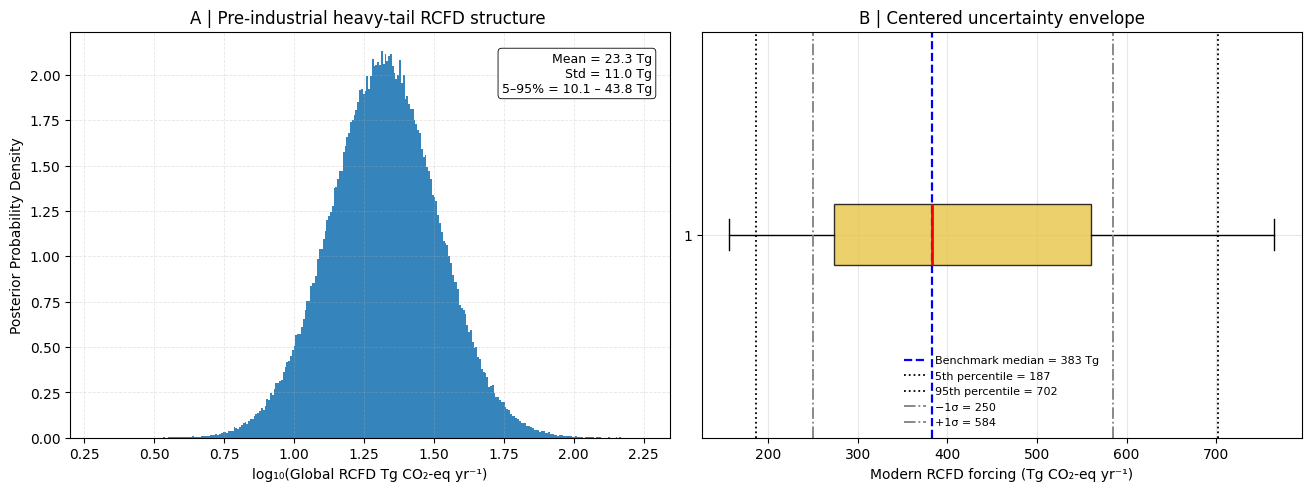

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000

# Create panel
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13,4.8), constrained_layout=True)
# FIG A : PRE-INDUSTRIAL
A_global_PI = norm.rvs(loc=22_000, scale=4_000, size=N)
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global_PI * kernel_frac
A_background = A_global_PI - A_kernel
kernel_flux = lognorm.rvs(s=0.45, scale=np.exp(7.15), size=N)
background_flux = lognorm.rvs(s=0.55, scale=np.exp(6.0), size=N)
floodplain_multiplier = uniform.rvs(loc=1.05, scale=0.15, size=N)
F_PI = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
F_PI_Tg = F_PI / 1e6
mean = np.mean(F_PI_Tg)
std  = np.std(F_PI_Tg)
p05, p50, p95 = np.percentile(F_PI_Tg, [5,50,95])
axA.hist(np.log10(F_PI_Tg), bins=300, density=True, alpha=0.9)
axA.grid(alpha=0.3, linestyle="--", linewidth=0.6)
axA.set_xlabel("log₁₀(Global RCFD Tg CO₂-eq yr⁻¹)")
axA.set_ylabel("Posterior Probability Density")
axA.set_title("A | Pre-industrial heavy-tail RCFD structure ")
stats_text = (
    f"Mean = {mean:.1f} Tg\n"
    f"Std = {std:.1f} Tg\n"
    f"5–95% = {p05:.1f} – {p95:.1f} Tg"
)
axA.text(0.97, 0.95, stats_text,
         transform=axA.transAxes,
         ha="right", va="top",
         fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.6))

# FIG B : MODERN ENVELOPE
F0 = 383
F_lo, F_hi = 156, 765
T = 1.2
betas = np.linspace(0.3, 1.4, 140)
Q10s  = np.linspace(1.8, 2.6, 140)
raw_vals = np.array([(1 + b*T) * q**(T/10) for b in betas for q in Q10s])
V_min, V_max = raw_vals.min(), raw_vals.max()
V_med = np.median(raw_vals)
def scale_to_target(v):
    if v <= V_med:
        return F_lo + (v - V_min) * (F0 - F_lo) / (V_med - V_min)
    else:
        return F0 + (v - V_med) * (F_hi - F0) / (V_max - V_med)
vals_scaled = np.array([scale_to_target(v) for v in raw_vals])
p05, p50, p95 = np.percentile(vals_scaled, [5, 50, 95])
mu = np.mean(vals_scaled)
sigma = np.std(vals_scaled)
lo_1s, hi_1s = mu - sigma, mu + sigma
axB.boxplot(vals_scaled, vert=False, patch_artist=True,
            medianprops={'color': 'red', 'linewidth': 2},
            boxprops=dict(facecolor="#e8c547", alpha=0.8))
axB.axvline(F0, color='blue', linestyle='--', lw=1.6, label=f"Benchmark median = {F0} Tg")
axB.axvline(p05, color='black', linestyle=':', lw=1.3, label=f"5th percentile = {p05:.0f}")
axB.axvline(p95, color='black', linestyle=':', lw=1.3, label=f"95th percentile = {p95:.0f}")
axB.axvline(lo_1s, color='gray', linestyle='-.', lw=1.3, label=f"−1σ = {lo_1s:.0f}")
axB.axvline(hi_1s, color='gray', linestyle='-.', lw=1.3, label=f"+1σ = {hi_1s:.0f}")
axB.set_xlabel("Modern RCFD forcing (Tg CO₂-eq yr⁻¹)")
axB.set_title("B | Centered uncertainty envelope")
axB.grid(alpha=0.3)
axB.legend(frameon=False, fontsize=8)

# Save panel
plt.savefig("Fig_PI_and_Modern_RCFD_Panel_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()

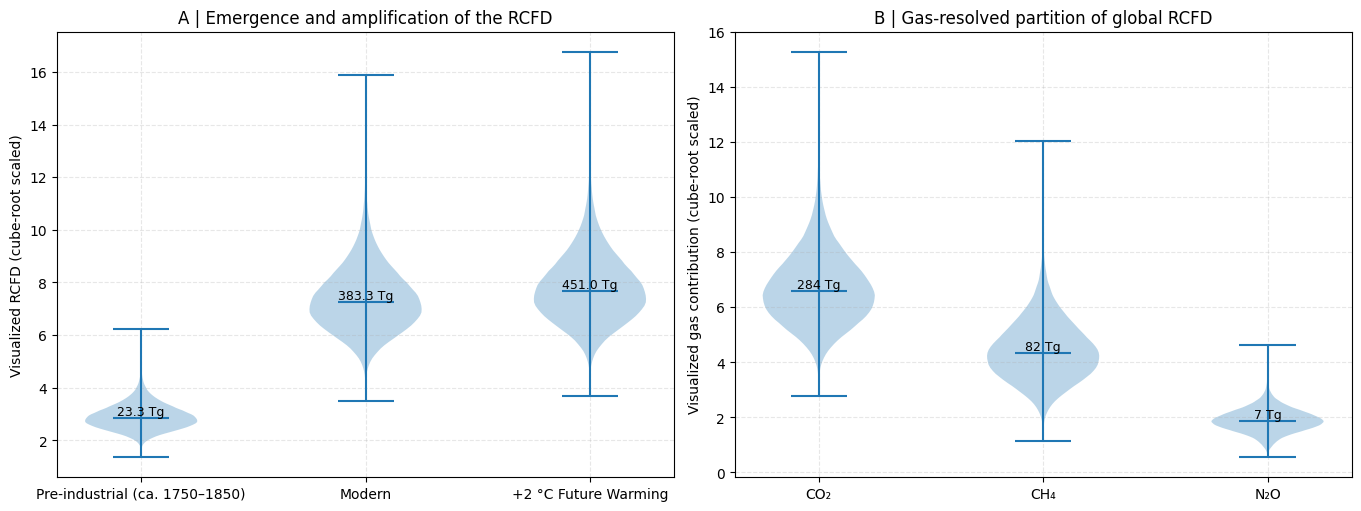

Pre-industrial median: 23.299999999999997
Modern median: 383.29999999999995
+2 °C future median: 450.79108933370736
CO₂ median: 284.3 Tg
CH₄ median: 81.7 Tg
N₂O median: 6.67 Tg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, beta, norm, uniform

N = 300_000

# Create panel
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5,5), constrained_layout=True)

#FIG A
A_global = norm.rvs(loc=97_000, scale=10_000, size=N)
kernel_frac = beta.rvs(a=5, b=5, size=N)
A_kernel = A_global * kernel_frac
A_background = A_global - A_kernel
kernel_flux = lognorm.rvs(s=0.50, scale=np.exp(8.2), size=N)
background_flux = lognorm.rvs(s=0.60, scale=np.exp(6.7), size=N)
floodplain_multiplier = uniform.rvs(loc=1.3, scale=0.5, size=N)
F_mod = (A_kernel * kernel_flux + A_background * background_flux) * floodplain_multiplier
F_mod = F_mod / 1e6
F_mod *= 383.3 / np.median(F_mod)
F_PI  = F_mod * (23.3 / 383.3)
Q10_eff = 2.25
F_fut = F_mod * (Q10_eff ** (2/10))
scale = lambda x: np.cbrt(x)
data = [scale(F_PI), scale(F_mod), scale(F_fut)]
labels = ["Pre-industrial (ca. 1750–1850)","Modern","+2 °C Future Warming"]
axA.violinplot(data, showmedians=True)
axA.set_xticks([1,2,3])
axA.set_xticklabels(labels)
axA.set_ylabel("Visualized RCFD (cube-root scaled)")
axA.set_title("A | Emergence and amplification of the RCFD")
axA.grid(alpha=0.3, linestyle="--")

true_vals = [23.3, 383.3, 451.0]
for i, val in enumerate(true_vals):
    axA.text(i+1, np.cbrt(val)+0.1, f"{val:.1f} Tg", ha="center", fontsize=9)

# FIG B
total_RCFD = lognorm.rvs(s=0.55, scale=np.exp(np.log(383)), size=N)
frac_CO2 = beta.rvs(a=12, b=4, size=N)
minor_pool = 1 - frac_CO2
frac_CH4_in_minor = beta.rvs(a=10, b=2, size=N)
frac_CH4 = minor_pool * frac_CH4_in_minor
frac_N2O = minor_pool - frac_CH4
frac_N2O = np.clip(frac_N2O, 0.003, 0.02)
frac_CH4 = minor_pool - frac_N2O
CO2 = total_RCFD * frac_CO2
CH4 = total_RCFD * frac_CH4
N2O = total_RCFD * frac_N2O
CO2s, CH4s, N2Os = scale(CO2), scale(CH4), scale(N2O)
axB.violinplot([CO2s, CH4s, N2Os], showmedians=True)
axB.set_xticks([1,2,3])
axB.set_xticklabels(["CO₂","CH₄","N₂O"])
axB.set_ylabel("Visualized gas contribution (cube-root scaled)")
axB.set_title("B | Gas-resolved partition of global RCFD")
for i, data_g in enumerate([CO2, CH4, N2O]):
    axB.text(i+1, np.cbrt(np.median(data_g)) + 0.1,
             f"{np.median(data_g):.0f} Tg", ha="center", fontsize=9)
axB.grid(alpha=0.3, linestyle="--")

# Save panel
plt.savefig("Fig_RCFD_Emergence_and_GasPartition_Panel_600dpi.png",
            dpi=600, bbox_inches="tight")
plt.show()
print("Pre-industrial median:", np.median(F_PI))
print("Modern median:", np.median(F_mod))
print("+2 °C future median:", np.median(F_fut))
print("CO₂ median:", round(np.median(CO2),1), "Tg")
print("CH₄ median:", round(np.median(CH4),1), "Tg")
print("N₂O median:", round(np.median(N2O),2), "Tg")

In [ ]:
import pandas as pd

# Load the dataset with semicolon as delimiter
file_path = "do_dws.csv"
df = pd.read_csv(file_path, sep=";", engine="python")

# Drop any empty column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip whitespace from column names and cell values
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Convert numeric columns safely
numeric_cols = ["Value", "Lat", "Lon"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Save clean version
clean_path = "do_dws_clean.csv"
df.to_csv(clean_path, index=False)
print("Cleaning complete! Saved as:", clean_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Cleaning complete! Saved as: do_dws_clean.csv
Shape: (2286, 6)
Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


/tmp/ipython-input-762100038.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
import pandas as pd

# Load file with semicolon as separator
file_path = "do_glorich.csv"  # replace with your actual path
df = pd.read_csv(file_path, sep=";", engine="python")

# Drop any empty column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip whitespace from headers and string cells
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Convert numeric columns safely
numeric_cols = ["Value", "Lat", "Lon"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep correct coordinate signs
# Save clean file
clean_path = "do_glorich_clean.csv"
df.to_csv(clean_path, index=False)
print("Cleaning complete! Saved as:", clean_path)
print("Rows:", df.shape[0])
print("Columns:", list(df.columns))
print("Latitude range:", (df["Lat"].min(), df["Lat"].max()))
print("Longitude range:", (df["Lon"].min(), df["Lon"].max()))

/tmp/ipython-input-4147825621.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


✅ Cleaning complete! Saved as: do_glorich_clean.csv
📊 Rows: 59265
📋 Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']
🌍 Latitude range: (-49.99, 68.37)
🌍 Longitude range: (-81.86, 39.82)


In [ ]:
import pandas as pd
# Load dataset
file_path = "do_waterbase.csv"  # change path if needed
df = pd.read_csv(file_path, sep=";", engine="python")
# Drop extra column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip whitespace from headers and text columns (apply only to object dtype)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

# Convert numeric columns safely
numeric_cols = ["Value", "Lat", "Lon"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Coordinate sanity check (Europe ≈ Lat 35–70°, Lon -10–30°)
lat_min, lat_max = df["Lat"].min(), df["Lat"].max()
lon_min, lon_max = df["Lon"].min(), df["Lon"].max()
print(f"Latitude range: {lat_min} → {lat_max}")
print(f"Longitude range: {lon_min} → {lon_max}")

# Save cleaned file
clean_path = "do_waterbase_clean.csv"
df.to_csv(clean_path, index=False)
print("Cleaning complete! Saved as:", clean_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

🌍 Latitude range: 34.72006 → 65.6013
🌍 Longitude range: -9.77516 → 33.3822
✅ Cleaning complete! Saved as: do_waterbase_clean.csv
📊 Shape: (80654, 6)
📋 Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


In [ ]:
import pandas as pd

# Load dataset
file_path = "file25.csv"   # replace with your file path if different
df = pd.read_csv(file_path, sep=";", engine="python")

# Drop extra unnamed columns (caused by leading ;)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip whitespace from column headers and cell text
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

# Convert numeric columns to float safely
numeric_cols = ["Value", "Lat", "Lon"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Quick coordinate sanity check (South America ≈ Lat −60 → +15, Lon −90 → −30)
lat_min, lat_max = df["Lat"].min(), df["Lat"].max()
lon_min, lon_max = df["Lon"].min(), df["Lon"].max()
print(f"Latitude range: {lat_min} → {lat_max}")
print(f"Longitude range: {lon_min} → {lon_max}")
# Save cleaned version
clean_path = "file25_clean.csv"
df.to_csv(clean_path, index=False)
print("Cleaning complete! Saved as:", clean_path)
print("Rows:", df.shape[0])
print("Columns:", list(df.columns))

Latitude range: 0.0 → 64.8025
Longitude range: -163.1325 → 0.0
Cleaning complete! Saved as: file25_clean.csv
Rows: 39606
Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


In [ ]:
import pandas as pd
# Explicit list of your uploaded cleaned files
files = [
    "do_dws_clean.csv",
    "do_glorich_clean.csv",
    "do_waterbase_clean.csv",
] + [f"file{i}_clean.csv" for i in range(0, 26)]  # file0_clean.csv to file25_clean.csv

# Read and combine them
dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
        dfs.append(df)
        print(f"Loaded {f} ({df.shape[0]} rows)")
    except Exception as e:
        print(f"Skipped {f} due to error: {e}")
# Concatenate into one dataframe
merged_df = pd.concat(dfs, ignore_index=True)
# Remove duplicate rows if any
merged_df.drop_duplicates(inplace=True)

# Save the merged dataset
merged_df.to_csv("merged_all_river_datasets.csv", index=False)
print("Merge complete!")
print("Final shape:", merged_df.shape)

Loaded do_dws_clean.csv (2286 rows)
Loaded do_glorich_clean.csv (59265 rows)
Loaded do_waterbase_clean.csv (80654 rows)
Loaded file0_clean.csv (99999 rows)
Loaded file1_clean.csv (99999 rows)
Loaded file2_clean.csv (99999 rows)
Loaded file3_clean.csv (99999 rows)
Loaded file4_clean.csv (99999 rows)
Loaded file5_clean.csv (99999 rows)
Loaded file6_clean.csv (99999 rows)
Loaded file7_clean.csv (62254 rows)
Loaded file8_clean.csv (99999 rows)
Loaded file9_clean.csv (99999 rows)
Loaded file10_clean.csv (99999 rows)
Loaded file11_clean.csv (99999 rows)
Loaded file12_clean.csv (99999 rows)
Loaded file13_clean.csv (99999 rows)
Loaded file14_clean.csv (96503 rows)
Loaded file15_clean.csv (99999 rows)
Loaded file16_clean.csv (99999 rows)
Loaded file17_clean.csv (99999 rows)
Loaded file18_clean.csv (99999 rows)
Loaded file19_clean.csv (99999 rows)
Loaded file20_clean.csv (99999 rows)
Loaded file21_clean.csv (99999 rows)
Loaded file22_clean.csv (99999 rows)
Loaded file23_clean.csv (99999 rows)
Lo

In [ ]:
import pandas as pd

file_path = "DO_GRQA.csv"

# Read raw lines
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

# Merge both cells per row
merged_lines = []
for line in lines:
    parts = line.strip().split(",", 1)
    if len(parts) == 2:
        merged_lines.append(parts[0] + parts[1])
    else:
        merged_lines.append(parts[0])
# Split properly by semicolon
split_df = pd.DataFrame([row.split(";") for row in merged_lines])
# Rename columns
split_df.columns = [f"col_{i}" for i in range(split_df.shape[1])]
# Extract relevant columns
clean_df = pd.DataFrame({
    "Station": split_df["col_7"].fillna(split_df["col_6"]),   # Prefer site_name, fallback site_id
    "Day": pd.to_datetime(split_df["col_3"], errors="coerce"),
    "Value": pd.to_numeric(split_df["col_16"], errors="coerce"),
    "Unit": split_df["col_21"].replace("", "mg/L"),
    "Lat": pd.to_numeric(split_df["col_1"], errors="coerce"),
    "Lon": pd.to_numeric(split_df["col_2"], errors="coerce")
})
# Drop missing or invalid records
clean_df.dropna(subset=["Lat", "Lon", "Value"], inplace=True)
# Save cleaned dataset
output_path = "DO_GRQA_clean.csv"
clean_df.to_csv(output_path, index=False)
print("Cleaned GRQA file saved as:", output_path)
print("Rows:", clean_df.shape[0])
print("Columns:", list(clean_df.columns))

/tmp/ipython-input-1495748793.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "Day": pd.to_datetime(split_df["col_3"], errors="coerce"),


Cleaned GRQA file saved as: DO_GRQA_clean.csv
Rows: 1193968
Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


In [ ]:
import pandas as pd
# Load dataset
file_path = "GRDO_GEE_HA_NHD.csv"
# Try UTF-8 first
try:
    df = pd.read_csv(file_path, low_memory=False)
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin-1", low_memory=False)
# Extract the most relevant DO + coordinate information
clean_df = pd.DataFrame({
    # Prefer textual SiteID, fallback to HYRIV_ID
    "Station": df.get("SiteID", df.get("HYRIV_ID")),
    # Time field
    "Day": pd.to_datetime(df.get("End_time"), errors="coerce"),
    # Dissolved oxygen mean value
    "Value": pd.to_numeric(df.get("DO_mgL_mean"), errors="coerce"),
    # Constant unit
    "Unit": "mg/L",
    # Latitude and Longitude
    "Lat": pd.to_numeric(df.get("Lat_WGS84", df.get("Latitude")), errors="coerce"),
    "Lon": pd.to_numeric(df.get("Lon_WGS84", df.get("Longitude")), errors="coerce")
})
# Remove missing or invalid rows
clean_df.dropna(subset=["Lat", "Lon", "Value"], inplace=True)
# Save clean file
output_path = "GRDO_GEE_HA_NHD_clean.csv"
clean_df.to_csv(output_path, index=False)
print("Cleaned dataset saved as:", output_path)
print("Rows:", clean_df.shape[0])
print("Columns:", list(clean_df.columns))

✅ Cleaned dataset saved as: GRDO_GEE_HA_NHD_clean.csv
📊 Rows: 125158
📋 Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


In [ ]:
import pandas as pd
# List all your final clean files
files = [
    "merged_all_river_datasets.csv",  # from the 26-region merge
    "DO_GRQA_clean.csv",              # GRQA formatted dataset
    "GRDO_GEE_HA_NHD_clean.csv"       # GEE/HydroATLAS dataset
]
# Read and concatenate all
dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
        dfs.append(df)
        print(f"Loaded {f}: {df.shape[0]} rows")
    except Exception as e:
        print(f"Could not load {f}: {e}")
merged_df = pd.concat(dfs, ignore_index=True)
# Drop duplicates
merged_df.drop_duplicates(inplace=True)
# Ensure column order is consistent
merged_df = merged_df[["Station", "Day", "Value", "Unit", "Lat", "Lon"]]
# Save merged master dataset
output_path = "Global_River_DO_Master.csv"
merged_df.to_csv(output_path, index=False)
print("Final global merged file saved as:", output_path)
print("Final shape:", merged_df.shape)
print("Columns:", list(merged_df.columns))

✅ Loaded merged_all_river_datasets.csv: 2540546 rows
✅ Loaded DO_GRQA_clean.csv: 1193968 rows
✅ Loaded GRDO_GEE_HA_NHD_clean.csv: 125158 rows
Final global merged file saved as: Global_River_DO_Master.csv
Final shape: (3782444, 6)
Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']


In [ ]:
import pandas as pd
# Load dataset (semicolon-separated)
file_path = "OXYGEN_ALL.csv"
df = pd.read_csv(file_path, sep=";", engine="python")
# Drop stray unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Standardize column names
df.columns = df.columns.str.strip()
df.rename(columns={
    "DO obs": "Value",
    "DO": "Value",
    "value": "Value"
}, inplace=True)
# Ensure final column order
expected_cols = ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']
df = df[[c for c in expected_cols if c in df.columns]]
# Clean whitespace
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)
# Convert numeric & datetime columns
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df["Lat"]   = pd.to_numeric(df["Lat"], errors="coerce")
df["Lon"]   = pd.to_numeric(df["Lon"], errors="coerce")
df["Day"]   = pd.to_datetime(df["Day"], errors="coerce")
# Drop missing or invalid values
df = df.dropna(subset=["Lat", "Lon", "Value"])
# Quick coordinate sanity check
print(f"Latitude range: {df['Lat'].min():.2f} → {df['Lat'].max():.2f}")
print(f"Longitude range: {df['Lon'].min():.2f} → {df['Lon'].max():.2f}")
# Save cleaned dataset
clean_path = "OXYGEN_ALL_clean.csv"
df.to_csv(clean_path, index=False)
print("\nCleaning complete! Saved as:", clean_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())

🌍 Latitude range: -89.29 → 72.33
🌍 Longitude range: -170.72 → 178.43

✅ Cleaning complete! Saved as: OXYGEN_ALL_clean.csv
📊 Shape: (3788804, 6)
📋 Columns: ['Station', 'Day', 'Value', 'Unit', 'Lat', 'Lon']
   Station        Day  Value  Unit       Lat       Lon
0        0 2011-09-28   9.63  mg/l -27.10371  26.52153
1        0 2011-10-18   7.28  mg/l -27.10371  26.52153
2        0 2011-11-15   3.86  mg/l -27.10371  26.52153
3        0 2012-07-31   3.04  mg/l -27.10371  26.52153
4        0 2012-08-29   3.06  mg/l -27.10371  26.52153


In [ ]:
import pandas as pd
import numpy as np
# File paths
master_path = "Global_River_DO_Master.csv"
new_path = "OXYGEN_ALL_clean.csv"
output_path = "Global_River_DO_Master_Final.csv"
# Load only coordinate + date info from master (small memory)
print("Loading master coordinate index")
master = pd.read_csv(master_path, usecols=["Lat", "Lon", "Day"], low_memory=False)
master["Lat_round"] = master["Lat"].round(4)
master["Lon_round"] = master["Lon"].round(4)
master["Day"] = pd.to_datetime(master["Day"], errors="coerce")
existing_coords = set(zip(master["Lat_round"], master["Lon_round"], master["Day"]))
del master  # free RAM
# Prepare output file (copy header from master)
header_written = False
chunk_size = 100_000
print("Merging in chunks... please wait")
chunk_iter = pd.read_csv(new_path, chunksize=chunk_size)
for i, chunk in enumerate(chunk_iter):
    chunk["Lat"] = pd.to_numeric(chunk["Lat"], errors="coerce")
    chunk["Lon"] = pd.to_numeric(chunk["Lon"], errors="coerce")
    chunk["Day"] = pd.to_datetime(chunk["Day"], errors="coerce")
    chunk["Lat_round"] = chunk["Lat"].round(4)
    chunk["Lon_round"] = chunk["Lon"].round(4)
    # Keep only new unique points
    mask_new = ~chunk.apply(lambda r: (r["Lat_round"], r["Lon_round"], r["Day"]) in existing_coords, axis=1)
    new_rows = chunk[mask_new]
    # Append new coordinate keys to memory
    new_coords = set(zip(new_rows["Lat_round"], new_rows["Lon_round"], new_rows["Day"]))
    existing_coords |= new_coords  # update seen points
    # Save cleaned new rows
    mode = "w" if not header_written else "a"
    new_rows.drop(columns=["Lat_round", "Lon_round"]).to_csv(output_path, mode=mode,
                                                            header=not header_written, index=False)
    header_written = True
    print(f"Chunk {i+1}: Added {len(new_rows)} new points")
print("\nMerge complete!")
print(f"Saved merged file: {output_path}")

🔹 Loading master coordinate index...
🚀 Merging in chunks... please wait
Chunk 1: Added 51349 new points
Chunk 2: Added 19374 new points
Chunk 3: Added 17795 new points
Chunk 4: Added 7750 new points
Chunk 5: Added 467 new points
Chunk 6: Added 58077 new points
Chunk 7: Added 41416 new points
Chunk 8: Added 58 new points
Chunk 9: Added 1066 new points
Chunk 10: Added 56260 new points
Chunk 11: Added 22118 new points
Chunk 12: Added 12804 new points
Chunk 13: Added 17602 new points
Chunk 14: Added 32657 new points
Chunk 15: Added 41873 new points
Chunk 16: Added 36877 new points
Chunk 17: Added 30861 new points
Chunk 18: Added 37273 new points
Chunk 19: Added 19665 new points
Chunk 20: Added 20972 new points
Chunk 21: Added 37397 new points
Chunk 22: Added 72818 new points
Chunk 23: Added 62739 new points
Chunk 24: Added 36273 new points
Chunk 25: Added 21287 new points
Chunk 26: Added 28262 new points
Chunk 27: Added 17405 new points
Chunk 28: Added 25158 new points
Chunk 29: Added 1094

In [ ]:
import pandas as pd
a = pd.read_csv("OXYGEN_ALL_clean.csv")
b = pd.read_csv("Global_River_DO_Master.csv")
combo = pd.concat([a, b], ignore_index=True)
combo.drop_duplicates(subset=["Lat","Lon","Day"], keep="first", inplace=True)
combo.to_csv("Global_River_DO_Master_Final.csv", index=False)
combo.drop_duplicates(subset=["Lat","Lon","Day","Value"], keep="first", inplace=True)
print("Union complete. Final unique points:", combo.shape[0])
print("Added new points:", combo.shape[0] - b.shape[0])
print("Total unique locations:", combo[['Lat','Lon']].drop_duplicates().shape[0])

Union complete. Final unique points: 4666571
Added new points: 884127
Total unique locations: 290316


In [ ]:
import pandas as pd; print(pd.read_csv("Global_River_DO_Master_Final.csv").drop_duplicates(subset=["Lat","Lon","Day"]).shape[0] - pd.read_csv("Global_River_DO_Master.csv").drop_duplicates(subset=["Lat","Lon","Day"]).shape[0])

/tmp/ipython-input-434923794.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  import pandas as pd; print(pd.read_csv("Global_River_DO_Master_Final.csv").drop_duplicates(subset=["Lat","Lon","Day"]).shape[0] - pd.read_csv("Global_River_DO_Master.csv").drop_duplicates(subset=["Lat","Lon","Day"]).shape[0])


1066276


In [ ]:
import pandas as pd
a = pd.read_csv("Global_River_DO_Master.csv")
b = pd.read_csv("Global_River_DO_Master_Final.csv")
print("Old master total rows:", len(a))
print("New master total rows:", len(b))
print("\nUnique coordinate pairs (Lat, Lon):")
print("Old:", a[['Lat','Lon']].drop_duplicates().shape[0])
print("New:", b[['Lat','Lon']].drop_duplicates().shape[0])
print("\nUnique (Lat, Lon, Day):")
print("Old:", a.drop_duplicates(subset=['Lat','Lon','Day']).shape[0])
print("New:", b.drop_duplicates(subset=['Lat','Lon','Day']).shape[0])

/tmp/ipython-input-1719036319.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  b = pd.read_csv("Global_River_DO_Master_Final.csv")


Old master total rows: 3782444
New master total rows: 4666571

Unique coordinate pairs (Lat, Lon):
Old: 260531
New: 290316

Unique (Lat, Lon, Day):
Old: 3600295
New: 4666571
